## 프로젝트: Seq2Seq으로 한국어-영어 번역기 만들기

#### 환경설정

In [1]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


In [2]:
!sudo apt update
!sudo apt-get install -y fonts-nanum

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
131 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 131 not upgraded.


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

PyTorch version: 2.7.1+cu118
NumPy version: 2.2.6
Pandas version: 2.3.0


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

사용 device: cuda
GPU: Tesla T4


In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [7]:
!pip install konlpy

In [9]:
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [10]:
!python -m pip install --upgrade pip setuptools wheel

In [11]:
!pip install konlpy
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [13]:
!grep -n "version" /tmp/mecab-python-0.996/setup.py

13:	version = "0.996",


In [14]:
!sed -i 's/version = cmd1("mecab-config --version"),/version = "0.996",/' /tmp/mecab-python-0.996/setup.py

In [15]:
!grep -n "version" /tmp/mecab-python-0.996/setup.py

13:	version = "0.996",


In [16]:
!pip install --no-build-isolation /tmp/mecab-python-0.996

Processing /tmp/mecab-python-0.996
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mecab-python: filename=mecab_python-0.996-cp312-cp312-linux_x86_64.whl size=45300 sha256=8fb6443cf310d1fb454c32337fa1e75f07309b798c37799bd12fd410d193b9c7
  Stored in directory: /home/jovyan/.cache/pip/wheels/ae/a0/de/25a271a9d8a1cf38cb848d1cda1cc6f7262211bc7a490c5632
Successfully built mecab-python
  Attempting uninstall: mecab-python
    Found existing installation: mecab-python 0.996
    Uninstalling mecab-python-0.996:
      Successfully uninstalled mecab-python-0.996


### 데이터 다운로드

In [17]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-park.train.tar.gz

--2026-05-06 06:57:20--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-06 06:57:21 ERROR 404: Not Found.



In [18]:
!tar -xvf korean-english-park.train.tar.gz

korean-english-park.train.en
korean-english-park.train.ko


In [9]:
with open("korean-english-park.train.ko", "r", encoding="utf-8") as f:
    ko_lines = f.readlines()

with open("korean-english-park.train.en", "r", encoding="utf-8") as f:
    en_lines = f.readlines()

print("한국어 샘플:")
print(ko_lines[:3])

print("\n영어 샘플:")
print(en_lines[:3])

한국어 샘플:
['개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"\n', '모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.\n', '그러나 이것은 또한 책상도 필요로 하지 않는다.\n']

영어 샘플:
['Much of personal computing is about "can you top this?"\n', 'so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.\n', "Like all optical mice, But it also doesn't need a desk.\n"]


### 데이터 정제

In [10]:
import re

def preprocess_sentence(sentence, lang="eng"):
    sentence = sentence.lower().strip()

    # 문장부호 앞뒤에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 여러 개의 공백을 하나로 정리
    sentence = re.sub(r'[" "]+', " ", sentence)

    if lang == "eng":
        # 영어, 문장부호만 남김
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    elif lang == "kor":
        # 한글, 자모, 문장부호만 남김
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence

print("슝~")

슝~


In [11]:
with open("korean-english-park.train.ko", "r", encoding="utf-8") as f:
    kor_lines = f.readlines()

with open("korean-english-park.train.en", "r", encoding="utf-8") as f:
    eng_lines = f.readlines()

print("한국어 데이터 수:", len(kor_lines))
print("영어 데이터 수:", len(eng_lines))

print(kor_lines[0])
print(eng_lines[0])

한국어 데이터 수: 94123
영어 데이터 수: 94123
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"

Much of personal computing is about "can you top this?"



In [12]:
cleaned_corpus = set()

for kor, eng in zip(kor_lines, eng_lines):
    kor = preprocess_sentence(kor, "kor")
    eng = preprocess_sentence(eng, "eng")

    # 빈 문장 제거
    if len(kor) == 0 or len(eng) == 0:
        continue

    # 타겟 언어인 영어에 <start>, <end> 토큰 추가
    eng = "<start> " + eng + " <end>"

    # 병렬 쌍이 흐트러지지 않도록 tuple 단위로 저장
    cleaned_corpus.add((kor, eng))

cleaned_corpus = list(cleaned_corpus)

print("중복 제거 후 데이터 수:", len(cleaned_corpus))
print(cleaned_corpus[0])

중복 제거 후 데이터 수: 78785
('전 세계 챔피언인 부넨은 결승선을 통과한 뒤 위로 통과한 것으로 착각해 손을 번쩍 들었으나 패배를 인정할 수 밖에 없었다 .', '<start> former world champion boonen at first thought he had had the last word and raised his arms in triumph but soon realised his lieutenant had beaten him . <end>')


In [23]:
!pip install mecab-python3

In [13]:
import MeCab

tagger = MeCab.Tagger()
print(tagger.parse("안녕하세요 저는 학생입니다."))

안녕	NNG,행위,T,안녕,*,*,*,*
하	XSV,*,F,하,*,*,*,*
세요	EP+EF,*,F,세요,Inflect,EP,EF,시/EP/*+어요/EF/*
저	NP,*,F,저,Inflect,NP,NP,제/NP/*
는	JX,*,T,는,*,*,*,*
학생	NNG,*,T,학생,*,*,*,*
입니다	VCP+EF,*,F,입니다,Inflect,VCP,EF,이/VCP/*+ᄇ니다/EF/*
.	SF,*,*,*,*,*,*,*
EOS



In [15]:
import MeCab
print(MeCab)
print(MeCab.Tagger)

<module 'MeCab' from '/opt/conda/lib/python3.12/site-packages/MeCab/__init__.py'>
<class 'MeCab.Tagger'>


In [16]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs("안녕하세요 저는 학생입니다."))

['안녕', '하', '세요', '저', '는', '학생', '입니다', '.']


In [17]:
kor_corpus = []
eng_corpus = []

for kor, eng in cleaned_corpus:
    kor_tokens = mecab.morphs(kor)
    eng_tokens = eng.split()

    if len(kor_tokens) <= 40 and len(eng_tokens) <= 40:
        kor_corpus.append(kor_tokens)
        eng_corpus.append(eng_tokens)

print("최종 한국어 문장 수:", len(kor_corpus))
print("최종 영어 문장 수:", len(eng_corpus))

print("한국어 예시:", kor_corpus[0])
print("영어 예시:", eng_corpus[0])

최종 한국어 문장 수: 62944
최종 영어 문장 수: 62944
한국어 예시: ['전', '세계', '챔피언', '인', '부', '넨', '은', '결승선', '을', '통과', '한', '뒤', '위', '로', '통과', '한', '것', '으로', '착각', '해', '손', '을', '번쩍', '들', '었', '으나', '패배', '를', '인정', '할', '수', '밖에', '없', '었', '다', '.']
영어 예시: ['<start>', 'former', 'world', 'champion', 'boonen', 'at', 'first', 'thought', 'he', 'had', 'had', 'the', 'last', 'word', 'and', 'raised', 'his', 'arms', 'in', 'triumph', 'but', 'soon', 'realised', 'his', 'lieutenant', 'had', 'beaten', 'him', '.', '<end>']


### 토큰화

In [18]:
from collections import Counter
import numpy as np
import torch

print("슝~")

슝~


In [20]:
class TextTokenizer:
    def __init__(self, vocab_size=12000):
        self.vocab_size = vocab_size
        self.word_index = {}
        self.index_word = {}

        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.start_token = "<start>"
        self.end_token = "<end>"

    def fit_on_texts(self, corpus, use_start_end=False):
        counter = Counter()

        for sentence in corpus:
            counter.update(sentence)

        # 특수 토큰 먼저 등록
        special_tokens = [self.pad_token, self.unk_token]

        if use_start_end:
            special_tokens += [self.start_token, self.end_token]

        for idx, token in enumerate(special_tokens):
            self.word_index[token] = idx
            self.index_word[idx] = token

        # 특수 토큰은 중복 등록 방지
        for token in special_tokens:
            if token in counter:
                del counter[token]

        most_common = counter.most_common(self.vocab_size - len(special_tokens))

        start_idx = len(special_tokens)

        for idx, (word, count) in enumerate(most_common, start=start_idx):
            self.word_index[word] = idx
            self.index_word[idx] = word

    def texts_to_sequences(self, corpus):
        sequences = []

        unk_id = self.word_index[self.unk_token]

        for sentence in corpus:
            sequence = [
                self.word_index.get(token, unk_id)
                for token in sentence
            ]
            sequences.append(sequence)

        return sequences

    def sequences_to_texts(self, sequences):
        texts = []

        for sequence in sequences:
            tokens = [
                self.index_word.get(idx, self.unk_token)
                for idx in sequence
                if idx != self.word_index[self.pad_token]
            ]
            texts.append(tokens)

        return texts

In [21]:
def pad_sequences_custom(sequences, max_len=None, padding_value=0):
    if max_len is None:
        max_len = max(len(seq) for seq in sequences)

    padded = []

    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]

        pad_len = max_len - len(seq)
        padded_seq = seq + [padding_value] * pad_len
        padded.append(padded_seq)

    return np.array(padded, dtype=np.int64)

In [22]:
def tokenize(corpus, vocab_size=12000, max_len=None, use_start_end=False):
    tokenizer = TextTokenizer(vocab_size=vocab_size)

    tokenizer.fit_on_texts(corpus, use_start_end=use_start_end)

    sequences = tokenizer.texts_to_sequences(corpus)

    tensor = pad_sequences_custom(
        sequences,
        max_len=max_len,
        padding_value=tokenizer.word_index["<pad>"]
    )

    return tensor, tokenizer

In [23]:
VOCAB_SIZE = 12000
MAX_LENGTH = 40

kor_tensor, kor_tokenizer = tokenize(
    kor_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH
)

eng_tensor, eng_tokenizer = tokenize(
    eng_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH
)

print("한국어 텐서 shape:", kor_tensor.shape)
print("영어 텐서 shape:", eng_tensor.shape)

print("한국어 vocab size:", len(kor_tokenizer.word_index))
print("영어 vocab size:", len(eng_tokenizer.word_index))

한국어 텐서 shape: (62944, 40)
영어 텐서 shape: (62944, 40)
한국어 vocab size: 12000
영어 vocab size: 12000


In [24]:
print("<pad> index:", eng_tokenizer.word_index.get("<pad>"))
print("<unk> index:", eng_tokenizer.word_index.get("<unk>"))
print("<start> index:", eng_tokenizer.word_index.get("<start>"))
print("<end> index:", eng_tokenizer.word_index.get("<end>"))

<pad> index: 0
<unk> index: 1
<start> index: 4
<end> index: 5


In [25]:
kor_tensor = torch.LongTensor(kor_tensor)
eng_tensor = torch.LongTensor(eng_tensor)

print(type(kor_tensor))
print(type(eng_tensor))

print(kor_tensor.shape)
print(eng_tensor.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([62944, 40])
torch.Size([62944, 40])


In [26]:
idx = 0

print("원본 한국어 토큰:")
print(kor_corpus[idx])

print("\n한국어 정수 텐서:")
print(kor_tensor[idx])

print("\n복원 한국어:")
print(kor_tokenizer.sequences_to_texts([kor_tensor[idx].tolist()]))

print("\n원본 영어 토큰:")
print(eng_corpus[idx])

print("\n영어 정수 텐서:")
print(eng_tensor[idx])

print("\n복원 영어:")
print(eng_tokenizer.sequences_to_texts([eng_tensor[idx].tolist()]))

원본 한국어 토큰:
['전', '세계', '챔피언', '인', '부', '넨', '은', '결승선', '을', '통과', '한', '뒤', '위', '로', '통과', '한', '것', '으로', '착각', '해', '손', '을', '번쩍', '들', '었', '으나', '패배', '를', '인정', '할', '수', '밖에', '없', '었', '다', '.']

한국어 정수 텐서:
tensor([   57,   102,  1370,    24,   463,  2704,     8, 11928,     6,   598,
           19,   228,   203,    22,   598,    19,    21,    20,  8068,    50,
          751,     6,     1,    16,    32,   574,  1384,    10,   492,    38,
           41,  1201,    71,    32,     3,     2,     0,     0,     0,     0])

복원 한국어:
[['전', '세계', '챔피언', '인', '부', '넨', '은', '결승선', '을', '통과', '한', '뒤', '위', '로', '통과', '한', '것', '으로', '착각', '해', '손', '을', '<unk>', '들', '었', '으나', '패배', '를', '인정', '할', '수', '밖에', '없', '었', '다', '.']]

원본 영어 토큰:
['<start>', 'former', 'world', 'champion', 'boonen', 'at', 'first', 'thought', 'he', 'had', 'had', 'the', 'last', 'word', 'and', 'raised', 'his', 'arms', 'in', 'triumph', 'but', 'soon', 'realised', 'his', 'lieutenant', 'had', 'beaten', 'him', '.', '

In [27]:
enc_vocab_size = len(kor_tokenizer.word_index)
dec_vocab_size = len(eng_tokenizer.word_index)

print("Encoder vocab size:", enc_vocab_size)
print("Decoder vocab size:", dec_vocab_size)

Encoder vocab size: 12000
Decoder vocab size: 12000


### 모델 설계

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

BATCH_SIZE = 64
EMBEDDING_DIM = 256
HIDDEN_SIZE = 512

enc_vocab_size = len(kor_tokenizer.word_index)
dec_vocab_size = len(eng_tokenizer.word_index)

print("Encoder vocab size:", enc_vocab_size)
print("Decoder vocab size:", dec_vocab_size)

사용 device: cuda
Encoder vocab size: 12000
Decoder vocab size: 12000


#### 엔코더 정의

In [29]:
print("kor_tensor max:", kor_tensor.max().item())
print("enc_vocab_size:", enc_vocab_size)

assert kor_tensor.max().item() < enc_vocab_size

kor_tensor max: 11999
enc_vocab_size: 12000


In [30]:
print("eng_tensor max:", eng_tensor.max().item())
print("dec_vocab_size:", dec_vocab_size)

assert eng_tensor.max().item() < dec_vocab_size

eng_tensor max: 11999
dec_vocab_size: 12000


In [52]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.2):
        super(Encoder, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        
    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        outputs, hidden = self.gru(embedded)
        
        return outputs, hidden

#### attention 정의

In [48]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        
        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)
        
    def forward(self, query, values):
        query = query.permute(1, 0, 2)
        
        score = self.V(
            torch.tanh(
                self.W1(values) + self.W2(query)
            )
        )
        
        attention_weights = F.softmax(score, dim=1)
        
        context_vector = attention_weights * values
        context_vector = torch.sum(context_vector, dim=1)
        
        return context_vector, attention_weights

#### 디코더 정의

In [49]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.2):
        super(Decoder, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_size)
        
        self.gru = nn.GRU(
            input_size=embedding_dim + hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(
            hidden,
            enc_output
        )
        
        x = x.unsqueeze(1)
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        context_vector = context_vector.unsqueeze(1)
        
        decoder_input = torch.cat(
            [context_vector, embedded],
            dim=-1
        )
        
        output, hidden = self.gru(decoder_input, hidden)
        output = output.squeeze(1)
        
        prediction = self.fc(output)
        
        return prediction, hidden, attention_weights

In [53]:
encoder = Encoder(
    vocab_size=enc_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

decoder = Decoder(
    vocab_size=dec_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

In [54]:
sample_input = kor_tensor[:BATCH_SIZE].to(device)
sample_target = eng_tensor[:BATCH_SIZE].to(device)

enc_output, enc_hidden = encoder(sample_input)

print("enc_output shape:", enc_output.shape)
print("enc_hidden shape:", enc_hidden.shape)

enc_output shape: torch.Size([64, 40, 512])
enc_hidden shape: torch.Size([1, 64, 512])


In [55]:
start_token_id = eng_tokenizer.word_index["<start>"]

dec_input = torch.tensor(
    [start_token_id] * BATCH_SIZE,
    dtype=torch.long
).to(device)

prediction, dec_hidden, attention_weights = decoder(
    dec_input,
    enc_hidden,
    enc_output
)

print("prediction shape:", prediction.shape)
print("dec_hidden shape:", dec_hidden.shape)
print("attention_weights shape:", attention_weights.shape)

prediction shape: torch.Size([64, 12000])
dec_hidden shape: torch.Size([1, 64, 512])
attention_weights shape: torch.Size([64, 40, 1])


### 모델 훈련

#### 데이터셋 로더

In [62]:
print("전체 데이터 수:", len(dataset))
print("BATCH_SIZE:", BATCH_SIZE)
print("배치 수:", len(dataloader))

전체 데이터 수: 62944
BATCH_SIZE: 64
배치 수: 983


In [63]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_tensor, tgt_tensor):
        self.src_tensor = src_tensor
        self.tgt_tensor = tgt_tensor

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        return self.src_tensor[idx], self.tgt_tensor[idx]


dataset = TranslationDataset(kor_tensor, eng_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

print("전체 데이터 수:", len(dataset))
print("배치 수:", len(dataloader))

전체 데이터 수: 62944
배치 수: 984


#### 옵티마이저 로스함수 설정

In [78]:
encoder = Encoder(
    vocab_size=enc_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

decoder = Decoder(
    vocab_size=dec_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=0.0001)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=0.0001)

criterion = nn.CrossEntropyLoss(
    ignore_index=0,
    reduction="sum"
)

#### 모델 훈련 설계

In [79]:
def train_step(
    encoder,
    decoder,
    dataloader,
    encoder_optimizer,
    decoder_optimizer,
    criterion
):
    encoder.train()
    decoder.train()

    total_loss = 0
    total_tokens = 0

    start_token_id = eng_tokenizer.word_index["<start>"]

    for src, tgt in dataloader:
        src = src.to(device)
        tgt = tgt.to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        enc_output, enc_hidden = encoder(src)
        dec_hidden = enc_hidden

        dec_input = torch.tensor(
            [start_token_id] * src.size(0),
            dtype=torch.long,
            device=device
        )

        loss = torch.tensor(0.0, device=device)
        non_pad_tokens = 0

        for t in range(1, tgt.size(1)):
            predictions, dec_hidden, _ = decoder(
                dec_input,
                dec_hidden,
                enc_output
            )

            target = tgt[:, t]

            loss = loss + criterion(predictions, target)
            non_pad_tokens += (target != 0).sum().item()

            dec_input = target

        if non_pad_tokens == 0:
            continue

        batch_loss = loss / non_pad_tokens

        if torch.isnan(batch_loss):
            print("NaN batch detected")
            continue

        batch_loss.backward()

        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()
        total_tokens += non_pad_tokens

    if total_tokens == 0:
        return float("nan")

    return total_loss / total_tokens

### 10에포크 훈련

In [80]:
%%time

EPOCHS = 10

loss_history = []
translation_history = []

for epoch in range(EPOCHS):
    train_loss = train_step(
        encoder,
        decoder,
        dataloader,
        encoder_optimizer,
        decoder_optimizer,
        criterion
    )

    loss_history.append(train_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    epoch_translations = print_test_translations(epoch)

    translation_history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "translations": epoch_translations
    })

Epoch 1/10, Train Loss: 6.1486

Epoch 1 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the <unk> of the <unk> of the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> of the <unk> of the <unk> . <end>

K3) 커피는 필요 없다.
토큰: ['커피', '는', '필요', '없', '다', '.']
E3) the <unk> of the <unk> of the <unk> . <end>

K4) 일곱 명의 사망자가 발생했다.
토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
E4) the <unk> of the <unk> of the <unk> . <end>

Epoch 2/10, Train Loss: 5.6008

Epoch 2 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the <unk> is the <unk> of the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> is a <unk> of the <unk> . <end>

K3) 커피는 필요 없다.
토큰: ['커피', '는', '필요', '없', '다', '.']
E3) the <unk> is a <unk> of the <unk> . <end>

K4) 일곱 명의 사망자가 발생했다.
토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
E4) the <unk> , the <unk> of the <unk> , the <unk> of the <unk> . <end>

### loss nan 발생  
- drop out
- 학습률 조정 0.001 => 0.0001
- 로스가 더디게 줄어들지만 nan은 발생하지 않음
- 단 unk>가 많이 발생


다시 개선을 위해 vacb size 증가와 에포크 수를 늘리기로 결정.

vacb size와 토큰 재설정

In [81]:
VOCAB_SIZE = 20000
EPOCHS = 20

EMBEDDING_DIM = 128
HIDDEN_SIZE = 256
BATCH_SIZE = 64

In [82]:
kor_tensor, kor_tokenizer = tokenize(
    kor_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH,
    use_start_end=False
)

eng_tensor, eng_tokenizer = tokenize(
    eng_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH,
    use_start_end=True
)

kor_tensor = torch.LongTensor(kor_tensor)
eng_tensor = torch.LongTensor(eng_tensor)

enc_vocab_size = len(kor_tokenizer.word_index)
dec_vocab_size = len(eng_tokenizer.word_index)

print("Encoder vocab size:", enc_vocab_size)
print("Decoder vocab size:", dec_vocab_size)

print("<pad>:", eng_tokenizer.word_index["<pad>"])
print("<unk>:", eng_tokenizer.word_index["<unk>"])
print("<start>:", eng_tokenizer.word_index["<start>"])
print("<end>:", eng_tokenizer.word_index["<end>"])

Encoder vocab size: 20000
Decoder vocab size: 20000
<pad>: 0
<unk>: 1
<start>: 2
<end>: 3


In [84]:
def check_unk_status(corpus, tensor, tokenizer, name):
    unk_id = tokenizer.word_index["<unk>"]
    pad_id = tokenizer.word_index["<pad>"]

    raw_unk_count = sum(
        token == "<unk>"
        for sentence in corpus
        for token in sentence
    )

    total_tokens = (tensor != pad_id).sum().item()
    unk_tokens = (tensor == unk_id).sum().item()

    print(f"[{name}]")
    print("corpus 안의 <unk> 개수:", raw_unk_count)
    print("tensor non-pad 토큰 수:", total_tokens)
    print("tensor <unk> 토큰 수:", unk_tokens)
    print("tensor <unk> 비율:", unk_tokens / total_tokens if total_tokens > 0 else 0)
    print()

check_unk_status(kor_corpus, kor_tensor, kor_tokenizer, "Korean")
check_unk_status(eng_corpus, eng_tensor, eng_tokenizer, "English")

[Korean]
corpus 안의 <unk> 개수: 0
tensor non-pad 토큰 수: 1520880
tensor <unk> 토큰 수: 21128
tensor <unk> 비율: 0.013891957287885962

[English]
corpus 안의 <unk> 개수: 0
tensor non-pad 토큰 수: 1466703
tensor <unk> 토큰 수: 23147
tensor <unk> 비율: 0.015781654499922616



In [85]:
dataset = TranslationDataset(kor_tensor, eng_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

print("전체 데이터 수:", len(dataset))
print("배치 수:", len(dataloader))

전체 데이터 수: 62944
배치 수: 983


In [86]:
encoder = Encoder(
    vocab_size=enc_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

decoder = Decoder(
    vocab_size=dec_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=0.0001)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=0.0001)

criterion = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")

In [87]:
%%time

loss_history = []
translation_history = []

for epoch in range(EPOCHS):
    train_loss = train_step(
        encoder,
        decoder,
        dataloader,
        encoder_optimizer,
        decoder_optimizer,
        criterion
    )

    loss_history.append(train_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    epoch_translations = print_test_translations(epoch)

    translation_history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "translations": epoch_translations
    })

Epoch 1/20, Train Loss: 6.7097

Epoch 1 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> of the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> of the <unk> . <end>

K3) 커피는 필요 없다.
토큰: ['커피', '는', '필요', '없', '다', '.']
E3) the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> of the <unk> . <end>

K4) 일곱 명의 사망자가 발생했다.
토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
E4) the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> of the <unk> . <end>

Epoch 2/20, Train Loss: 6.1693

Epoch 2 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the <unk> , the <unk> , the <unk> , the <unk> , the <unk> , the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> , the <unk> , the <unk> , the <unk> , the <u

### 보캡 사이즈가 너무 크니 로스가 너무 더디게 떨어지게 되었다.  
- 문장구조는 매끄러우나 단어를 잘 매칭 시키지 못하게 되었다.
  
VOCAB_SIZE = 16000   
MAX_LENGTH = 40  

EMBEDDING_DIM = 256   
HIDDEN_SIZE = 512   

BATCH_SIZE = 128   
EPOCHS = 25   
LEARNING_RATE = 0.0003   
TEACHER_FORCING_RATIO = 0.7로 조정해서 다시 학습 시켜 보기

In [96]:
check_kor_words = [
    "오바마", "대통령",
    "시민", "도시", "속", "산다",
    "커피", "필요", "없",
    "일곱", "사망자", "발생"
]

for word in check_kor_words:
    print(word, kor_tokenizer.word_index.get(word))

오바마 111
대통령 48
시민 530
도시 298
속 540
산다 None
커피 2419
필요 250
없 71
일곱 6763
사망자 431
발생 84


In [90]:
VOCAB_SIZE = 17000
MAX_LENGTH = 40

EMBEDDING_DIM = 256
HIDDEN_SIZE = 512

BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 0.0003
TEACHER_FORCING_RATIO = 0.7

In [91]:
kor_tensor, kor_tokenizer = tokenize(
    kor_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH,
    use_start_end=False
)

eng_tensor, eng_tokenizer = tokenize(
    eng_corpus,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LENGTH,
    use_start_end=True
)

kor_tensor = torch.LongTensor(kor_tensor)
eng_tensor = torch.LongTensor(eng_tensor)

enc_vocab_size = len(kor_tokenizer.word_index)
dec_vocab_size = len(eng_tokenizer.word_index)

print("Encoder vocab size:", enc_vocab_size)
print("Decoder vocab size:", dec_vocab_size)

print("<pad>:", eng_tokenizer.word_index["<pad>"])
print("<unk>:", eng_tokenizer.word_index["<unk>"])
print("<start>:", eng_tokenizer.word_index["<start>"])
print("<end>:", eng_tokenizer.word_index["<end>"])

Encoder vocab size: 17000
Decoder vocab size: 17000
<pad>: 0
<unk>: 1
<start>: 2
<end>: 3


In [92]:
check_eng_words = [
    "obama", "president",
    "citizens", "people", "city", "live", "lives",
    "coffee", "need", "needs", "necessary", "not",
    "seven", "died", "dead", "killed"
]

for word in check_eng_words:
    print(word, eng_tokenizer.word_index.get(word))

obama 104
president 54
citizens 1206
people 42
city 122
live 521
lives 884
coffee 3152
need 473
needs 1105
necessary 1503
not 35
seven 396
died 180
dead 327
killed 106


In [93]:
dataset = TranslationDataset(kor_tensor, eng_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

print("전체 데이터 수:", len(dataset))
print("배치 수:", len(dataloader))

전체 데이터 수: 62944
배치 수: 491


In [98]:
encoder = Encoder(
    vocab_size=enc_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

decoder = Decoder(
    vocab_size=dec_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=0.2
).to(device)

encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=0.0003)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=0.0003)

criterion = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")

In [99]:
scheduler_encoder = torch.optim.lr_scheduler.StepLR(
    encoder_optimizer,
    step_size=8,
    gamma=0.5
)

scheduler_decoder = torch.optim.lr_scheduler.StepLR(
    decoder_optimizer,
    step_size=8,
    gamma=0.5
)

In [100]:
%%time

loss_history = []
translation_history = []

for epoch in range(EPOCHS):
    train_loss = train_step(
        encoder,
        decoder,
        dataloader,
        encoder_optimizer,
        decoder_optimizer,
        criterion
    )

    loss_history.append(train_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    epoch_translations = print_test_translations(epoch)

    translation_history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "translations": epoch_translations
    })
    scheduler_encoder.step()
    scheduler_decoder.step()
    print(
        "Current LR:",
        scheduler_encoder.get_last_lr()[0],
        scheduler_decoder.get_last_lr()[0]
    )

Epoch 1/25, Train Loss: 6.2366

Epoch 1 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the <unk> of the <unk> of the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> of the <unk> of the <unk> . <end>

K3) 커피는 필요 없다.
토큰: ['커피', '는', '필요', '없', '다', '.']
E3) the <unk> of the <unk> of the <unk> , the <unk> . <end>

K4) 일곱 명의 사망자가 발생했다.
토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
E4) the <unk> of the <unk> of the <unk> , the <unk> of the <unk> . <end>

Current LR: 0.0003 0.0003
Epoch 2/25, Train Loss: 5.6345

Epoch 2 번역 결과
K1) 오바마는 대통령이다.
토큰: ['오바마', '는', '대통령', '이', '다', '.']
E1) the president is a <unk> of the <unk> . <end>

K2) 시민들은 도시 속에 산다.
토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
E2) the <unk> of the <unk> <unk> <unk> <unk> <unk> <unk> . <end>

K3) 커피는 필요 없다.
토큰: ['커피', '는', '필요', '없', '다', '.']
E3) the <unk> is a <unk> of the <unk> . <end>

K4) 일곱 명의 사망자가 발생했다.
토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했

최종 실험에서는 vocabulary size, epoch 수, learning rate scheduler를 조정하여 모델을 재학습하였다. 그 결과 training loss는 3.6137까지 감소하였다. 번역 결과에서 일부 문장은 여전히 `<unk>` 토큰을 포함하였지만, “오바마는 대통령이다”는 `obama is a president .`로 번역되어 의미가 잘 전달되었고, “일곱 명의 사망자가 발생했다”는 `people have died` 표현을 포함하여 핵심 의미가 반영되었다. 이를 통해 Attention 기반 Seq2Seq 모델이 한국어-영어 번역 패턴을 일정 수준 학습했음을 확인하였다.

### 번역 예문 준비

In [72]:
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

In [73]:
def translate_sentence(sentence, max_length=40):
    encoder.eval()
    decoder.eval()

    input_tensor, input_tokens = sentence_to_tensor(
        sentence,
        kor_tokenizer,
        max_length=max_length
    )

    result = []
    attention_plot = []

    with torch.no_grad():
        enc_output, enc_hidden = encoder(input_tensor)
        dec_hidden = enc_hidden

        start_token_id = eng_tokenizer.word_index["<start>"]
        end_token_id = eng_tokenizer.word_index["<end>"]

        dec_input = torch.tensor(
            [start_token_id],
            dtype=torch.long,
            device=device
        )

        for t in range(max_length):
            predictions, dec_hidden, attention_weights = decoder(
                dec_input,
                dec_hidden,
                enc_output
            )

            predicted_id = torch.argmax(predictions, dim=1).item()

            predicted_word = eng_tokenizer.index_word.get(
                predicted_id,
                "<unk>"
            )

            result.append(predicted_word)

            attention_plot.append(
                attention_weights.squeeze(-1).cpu().numpy()[0]
            )

            if predicted_id == end_token_id:
                break

            dec_input = torch.tensor(
                [predicted_id],
                dtype=torch.long,
                device=device
            )

    return " ".join(result), input_tokens, attention_plot

In [74]:
def print_test_translations(epoch):
    print("\n" + "=" * 80)
    print(f"Epoch {epoch + 1} 번역 결과")
    print("=" * 80)

    results = []

    for i, sentence in enumerate(test_sentences, start=1):
        translation, input_tokens, attention_plot = translate_sentence(sentence)

        print(f"K{i}) {sentence}")
        print(f"토큰: {input_tokens}")
        print(f"E{i}) {translation}")
        print()

        results.append(translation)

    return results

In [75]:
import re
import torch

def preprocess_korean(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence


def sentence_to_tensor(sentence, tokenizer, max_length=40):
    sentence = preprocess_korean(sentence)

    # Mecab 형태소 분석
    tokens = mecab.morphs(sentence)

    unk_id = tokenizer.word_index["<unk>"]
    pad_id = tokenizer.word_index["<pad>"]

    sequence = [
        tokenizer.word_index.get(token, unk_id)
        for token in tokens
    ]

    sequence = sequence[:max_length]
    sequence += [pad_id] * (max_length - len(sequence))

    tensor = torch.LongTensor(sequence).unsqueeze(0).to(device)

    return tensor, tokens

print("sentence_to_tensor 준비 완료")

sentence_to_tensor 준비 완료


In [76]:
def sentence_to_tensor(sentence, tokenizer, max_length=40):
    sentence = preprocess_korean(sentence)

    # Mecab 형태소 분석
    tokens = mecab.morphs(sentence)

    # 토큰을 정수 인덱스로 변환
    unk_id = tokenizer.word_index["<unk>"]
    pad_id = tokenizer.word_index["<pad>"]

    sequence = [
        tokenizer.word_index.get(token, unk_id)
        for token in tokens
    ]

    # 길이 제한
    sequence = sequence[:max_length]

    # padding
    sequence += [pad_id] * (max_length - len(sequence))

    tensor = torch.LongTensor(sequence).unsqueeze(0).to(device)

    return tensor, tokens

sentence_to_tensor()
→ translate_sentence()
→ print_test_translations()
→ plot_attention()
→ 학습 루프 또는 번역 테스트

### attention 시각화 함수 정의

In [101]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_attention(attention, input_tokens, output_tokens):
    attention = np.array(attention)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)

    cax = ax.matshow(attention, cmap="viridis")
    fig.colorbar(cax)

    ax.set_xticklabels([""] + input_tokens, rotation=90)
    ax.set_yticklabels([""] + output_tokens)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel("Input Korean Tokens")
    plt.ylabel("Output English Tokens")
    plt.title("Attention Map")

    plt.show()

입력: 오바마는 대통령이다.
번역: obama is a president . <end>


/tmp/ipykernel_8116/330635483.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + input_tokens, rotation=90)
/tmp/ipykernel_8116/330635483.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + output_tokens)


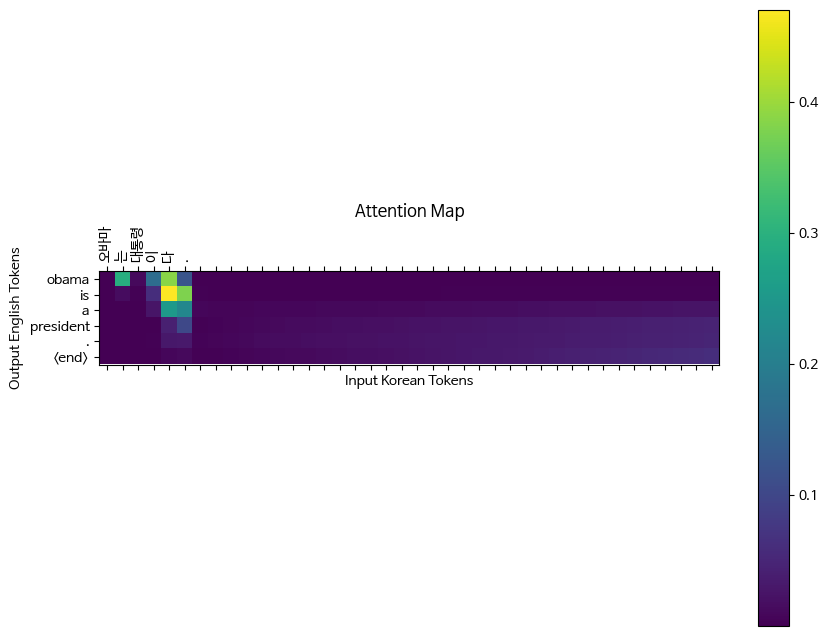

In [102]:
sentence = "오바마는 대통령이다."

translation, input_tokens, attention_plot = translate_sentence(sentence)

output_tokens = translation.split()

print("입력:", sentence)
print("번역:", translation)

plot_attention(
    attention_plot,
    input_tokens,
    output_tokens
)